# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SajidurCodes/flyrank-ml-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, json as jsonlib
from pathlib import Path
from dotenv import load_dotenv
import duckdb
import pandas as pd
import numpy as np

PROJECT_ROOT = Path(r"C:\Projects AI ML\flyrank-ml-starter")
load_dotenv(PROJECT_ROOT / ".env", override=True)
HF_TOKEN = os.getenv("HF_TOKEN")

con = duckdb.connect()
con.execute("CREATE SECRET hf_token (TYPE huggingface, TOKEN ?)", [HF_TOKEN])

WAREHOUSE = "hf://datasets/FlyRank/internship-warehouse"
FACT_MARCH = f"{WAREHOUSE}/fact_content_daily_performance/month=2026-03/*.parquet"
FACT_APRIL = f"{WAREHOUSE}/fact_content_daily_performance/month=2026-04/*.parquet"
DIM_CONTENT = f"{WAREHOUSE}/dim_content.parquet"
DECISION_CUTOFF = "2026-03-31"

MODEL_DATA = con.sql(f"""
    WITH march AS (
        SELECT
            client_hash_id, content_hash_id,
            SUM(gsc_clicks) AS clicks_march,
            SUM(gsc_impressions) AS impressions_march,
            AVG(gsc_avg_position) AS avg_position_march,
            SUM(gsc_clicks) / NULLIF(SUM(gsc_impressions), 0) AS ctr_march
        FROM read_parquet('{FACT_MARCH}')
        GROUP BY client_hash_id, content_hash_id
    ),
    april AS (
        SELECT client_hash_id, content_hash_id, SUM(gsc_clicks) AS clicks_april
        FROM read_parquet('{FACT_APRIL}')
        GROUP BY client_hash_id, content_hash_id
    ),
    content AS (
        SELECT
            client_hash_id, content_hash_id,
            content_type, main_intent, word_count, char_count,
            DATE_DIFF('day', content_updated_date, DATE '{DECISION_CUTOFF}') AS days_stale
        FROM read_parquet('{DIM_CONTENT}')
        WHERE is_published IS TRUE AND is_deleted IS FALSE
          AND content_updated_date <= DATE '{DECISION_CUTOFF}'
    ),
    position_benchmark AS (
        SELECT ROUND(avg_position_march) AS position_bucket, AVG(ctr_march) AS expected_ctr
        FROM march GROUP BY ROUND(avg_position_march)
    )
    SELECT
        m.client_hash_id, m.content_hash_id, m.clicks_march, m.impressions_march, a.clicks_april,
        m.ctr_march, m.avg_position_march,
        GREATEST(pb.expected_ctr - m.ctr_march, 0) AS ctr_gap,
        c.content_type, c.main_intent, c.word_count, c.char_count, c.days_stale,
        CASE WHEN (a.clicks_april - m.clicks_march) / NULLIF(m.clicks_march, 0) < -0.15 THEN 1 ELSE 0 END AS declined
    FROM march m
    JOIN april a USING (client_hash_id, content_hash_id)
    JOIN content c USING (client_hash_id, content_hash_id)
    JOIN position_benchmark pb ON ROUND(m.avg_position_march) = pb.position_bucket
    WHERE m.clicks_march >= 5
""").df()

FEATURE_COLS_NUMERIC = ["ctr_march", "avg_position_march", "ctr_gap", "word_count", "char_count", "days_stale"]
FEATURE_COLS_CATEGORICAL = ["content_type", "main_intent"]
TARGET_COL = "declined"

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), FEATURE_COLS_NUMERIC),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="missing")), ("encode", OneHotEncoder(handle_unknown="ignore"))]), FEATURE_COLS_CATEGORICAL),
])
final_model = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])
final_model.fit(MODEL_DATA[FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL], MODEL_DATA[TARGET_COL])

print("Rows:", len(MODEL_DATA))
print("Final model trained on all rows (this is the deployed queue, not a further validation step).")


Rows: 3290
Final model trained on all rows (this is the deployed queue, not a further validation step).


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Every page gets: a model probability (declining risk), a reason code (which signal drove the score — these double as the lane's "archetypes" for Refresh/Content Opportunity Scoring, since this lane doesn't use k-means clusters), and one action label.

**Reason codes (the archetype→action mapping for this lane):**
| reason_code | archetype meaning | → action |
|---|---|---|
| `CTR_GAP_ONLY` | Visible, ranks fine, underconverting on clicks for its position | → `CTR_FIX` |
| `STALE_LOW_CTR` | Both stale and underconverting | → `REFRESH` |
| `STALE_ONLY` | Old content, CTR is fine (rare — w04/w06 found staleness alone barely matters) | → `REFRESH` (low priority) |
| `HEALTHY` | Neither signal fires | → `PROTECT` |

**The decay/refresh insight, stated plainly:** across w04 and w06, the CTR-gap signal was the only one that held up under testing — staleness on its own was MIXED/leaning FALSE with tiny effect sizes. This playbook is honest about that: `STALE_ONLY` pages get a `REFRESH` label but are explicitly flagged as **lower-confidence** than `CTR_GAP`-driven picks, because the underlying signal test never confirmed staleness as reliable in isolation.

In [2]:
# --- Score every page, assign reason code + action, rank ---

def normalize(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

QUEUE = MODEL_DATA.copy()
QUEUE["model_score"] = final_model.predict_proba(QUEUE[FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL])[:, 1]

staleness_norm = normalize(QUEUE["days_stale"])
ctr_gap_norm = normalize(QUEUE["ctr_gap"])

def reason_code(row_stale, row_ctr):
    if row_stale > 0.5 and row_ctr > 0.5:
        return "STALE_LOW_CTR"
    if row_stale > 0.5:
        return "STALE_ONLY"
    if row_ctr > 0.5:
        return "CTR_GAP_ONLY"
    return "HEALTHY"

QUEUE["reason_code"] = [reason_code(s, c) for s, c in zip(staleness_norm, ctr_gap_norm)]

ACTION_MAP = {
    "STALE_LOW_CTR": "REFRESH",
    "CTR_GAP_ONLY": "CTR_FIX",
    "STALE_ONLY": "REFRESH",   # low-confidence, see Section 1 note
    "HEALTHY": "PROTECT",
}
QUEUE["action"] = QUEUE["reason_code"].map(ACTION_MAP)
QUEUE.loc[(QUEUE["reason_code"] == "STALE_ONLY"), "confidence"] = "low"
QUEUE["confidence"] = QUEUE["confidence"].fillna("standard")
QUEUE.loc[QUEUE["model_score"] < 0.3, "action"] = "MONITOR"  # low model risk overrides an isolated signal firing

QUEUE = QUEUE.sort_values("model_score", ascending=False).reset_index(drop=True)

print(QUEUE["action"].value_counts())
print(QUEUE["reason_code"].value_counts())
QUEUE.head(10)


action
PROTECT    3237
CTR_FIX      51
REFRESH       2
Name: count, dtype: int64
reason_code
HEALTHY         3237
CTR_GAP_ONLY      51
STALE_ONLY         2
Name: count, dtype: int64


,client_hash_id,content_hash_id,clicks_march,impressions_march,clicks_april,ctr_march,avg_position_march,ctr_gap,content_type,main_intent,word_count,char_count,days_stale,declined,model_score,reason_code,action,confidence
0,client_73cda7b4e4f265ea,content_aebfe5207a01df69,21.0,12110.0,21.0,0.001734,1.210232,0.015974,keyword article,informational,<NA>,<NA>,34,0,0.702909,CTR_GAP_ONLY,CTR_FIX,standard
1,client_a80fca3f171ed1de,content_551c233e798baddf,11.0,8520.0,31.0,0.001291,1.232790,0.016417,keyword article,informational,2691,17851,36,0,0.697319,CTR_GAP_ONLY,CTR_FIX,standard
2,client_73cda7b4e4f265ea,content_502ad65d0b770851,21.0,14158.0,1.0,0.001483,1.210969,0.016225,keyword article,informational,3177,21087,34,1,0.696654,CTR_GAP_ONLY,CTR_FIX,standard
3,client_73cda7b4e4f265ea,content_f2a580fd75a01906,11.0,14194.0,2.0,0.000775,1.113465,0.016933,keyword article,informational,2548,17687,34,1,0.694390,CTR_GAP_ONLY,CTR_FIX,standard
4,client_73cda7b4e4f265ea,content_a5398cc741369689,17.0,7754.0,3.0,0.002192,0.960602,0.015516,keyword article,informational,2864,19072,34,1,0.687372,CTR_GAP_ONLY,CTR_FIX,standard
5,client_73cda7b4e4f265ea,content_bd1937feddb8773d,9.0,2316.0,6.0,0.003886,1.267662,0.013822,keyword article,informational,<NA>,<NA>,34,1,0.681083,CTR_GAP_ONLY,CTR_FIX,standard
6,client_73cda7b4e4f265ea,content_9d2be85413dd12ca,6.0,5256.0,1.0,0.001142,1.468273,0.016567,keyword article,commercial,<NA>,<NA>,34,1,0.666739,CTR_GAP_ONLY,CTR_FIX,standard
7,client_73cda7b4e4f265ea,content_ecd6c58714e796eb,9.0,2407.0,3.0,0.003739,1.160893,0.013969,keyword article,informational,2650,18421,34,1,0.663927,CTR_GAP_ONLY,CTR_FIX,standard
8,client_20259bd6705d81d4,content_1d2dc429b857b82c,8.0,6376.0,4.0,0.001255,4.743185,0.004393,keyword article,informational,3752,24261,124,1,0.661558,HEALTHY,PROTECT,standard
9,client_73cda7b4e4f265ea,content_f78c4dac3f29f067,9.0,4975.0,6.0,0.001809,1.471852,0.015899,keyword article,commercial,<NA>,<NA>,34,1,0.659660,CTR_GAP_ONLY,CTR_FIX,standard


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** a content team's monthly triage aid for the Refresh / Content Opportunity Scoring lane. It ranks pages to prioritize *human* review time — not to auto-trigger edits, republishing, or budget decisions.

**Where it stops being valid:**
- **The label window.** The model was trained on a March→April decline definition (>15% click drop). It has no evidence about longer horizons, seasonal categories, or clients onboarded after March — using this queue on a different month's data without retraining is an extrapolation, not a validated use.
- **Sample size.** The w06 validation ran on a 159-row client-held-out test set. Precision@10% (0.800) is a real, measured number, but it's built on roughly 16 top-decile pages — small enough that individual-page confidence should stay modest even where portfolio-level ranking is useful.
- **Weak overall discrimination.** ROC-AUC sat at ~0.53, barely above chance, across every split tested in w06. This queue is useful for *ordering* pages by relative priority; it is not validated as an accurate probability of decline for any single page.
- **Confirmed vs. unconfirmed signals.** Only CTR-gap-vs-position was confirmed as predictive (w04, w06). Staleness was MIXED/leaning FALSE. `STALE_ONLY` rows are marked `confidence: low` in the queue for exactly this reason — this is not a hedge, it's a direct consequence of the signal test failing to confirm.
- **Excluded clients.** Clients without GA4 history for March, or without published/non-deleted content as of the March cutoff, are absent from this queue entirely — see w03/w04 for why.

In [3]:
# Section 2 is markdown-only — no query needed beyond what's already run above.
print('See markdown cell above.')


See markdown cell above.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any `REFRESH` or `CTR_FIX` row, a human must check:**
1. The page's actual content — the model has no idea what the page says, only aggregate numbers. A `CTR_GAP_ONLY` label doesn't mean the fix is obvious; someone has to read the page and the SERP.
2. Whether a recent, unlogged change already happened (a manual edit made after the March 31 cutoff that this queue can't see).
3. Business context the warehouse doesn't carry — a page nearing planned retirement, a seasonal page correctly quiet outside season, a legal/compliance page that shouldn't be touched for SEO reasons.

**No-go list — never automate these, full stop:**
- **Never auto-publish content changes** based on this score. The model outputs a priority order, not an edit.
- **Never treat `model_score` as a probability of decline for an individual page** in client-facing reporting — it's validated as a ranking tool on a 159-row test set, not as a calibrated per-page probability (see Section 2).
- **Never merge/delete pages** based on this queue — that's the cannibalization/consolidation problem, a different question this notebook doesn't touch.
- **Never re-run this queue on a different lane's clients without re-checking the exclusion filters** (`is_published`, `is_deleted`, GA4 onboarding) — silently reusing the query elsewhere risks re-introducing the exact leakage this track spent w03-w06 catching.
- **Never act on `STALE_ONLY` rows with the same confidence as `CTR_GAP`-driven rows** — flagged `confidence: low` for a reason; treat as "worth a look," not "known issue."

In [4]:
# Section 3 is markdown-only.
print('See markdown cell above.')


See markdown cell above.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Retrain triggers (any one of these should prompt a re-run, not a full rebuild):**
- A new month's data becomes available and the label window can roll forward (March→April becomes April→May, etc.) — the model should never be scoring more than one month past its training window without a refresh.
- The `reason_code` distribution shifts sharply month over month (e.g. `HEALTHY` share drops by >15 points) — could mean either a real portfolio shift or a schema/pipeline break upstream (we hit exactly this kind of surprise with `dim_content`'s snapshot-date issue in w04/w05 — a silent distribution shift is often a data problem before it's a real trend).
- `client_has_ga4` / `client_has_gsc` onboarding coverage changes meaningfully — new clients joining mid-lane changes who's even eligible to appear in the queue.

**Monitoring — check monthly, cheap and mechanical:**
- Re-run the Section 3 leakage assertions from w06 (`content_updated_date <= cutoff`, target column not in features) every time this notebook re-runs — they're assertions, so a broken pipeline fails loudly instead of silently producing a bad queue.
- Track Precision@10% on each new month's held-out client group over time — if it drifts well below the 0.800 baseline from w06, that's a signal the model's stopped generalizing, not just noise.
- Spot-check 5 `STALE_ONLY` rows and 5 `CTR_GAP_ONLY` rows by hand each month (same "weak picks" discipline from w04 Section 4) — cheap, catches drift a metric alone won't.

In [5]:
# Section 4 is markdown-only.
print('See markdown cell above.')


See markdown cell above.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to `work/outputs/` — your paper builds on these files.*

- **CSV** → `work/outputs/action_playbook_queue.csv` — stays out of git (CI leak-guard), regenerated on every run.
- **Metrics JSON** → `work/outputs/w07_metrics.json` — the receipts: real w06 validation numbers, reason_code/action distributions. This DOES get committed.
- **Figure** → `work/figures/reason_code_distribution.png` — committed, reused directly in the paper's Results/Recommendations section.

Wrote 3290 rows to C:\Projects AI ML\flyrank-ml-starter\work\outputs\action_playbook_queue.csv
Wrote metrics to C:\Projects AI ML\flyrank-ml-starter\work\outputs\w07_metrics.json


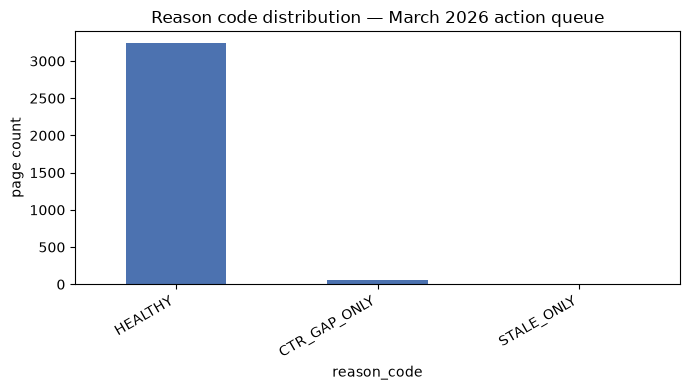

Wrote figure to C:\Projects AI ML\flyrank-ml-starter\work\figures\reason_code_distribution.png


In [ ]:
import matplotlib.pyplot as plt

# --- CSV export ---
out_csv = PROJECT_ROOT / "work" / "outputs" / "action_playbook_queue.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
QUEUE.to_csv(out_csv, index=False)
print(f"Wrote {len(QUEUE)} rows to {out_csv}")

# --- Metrics JSON export ---
metrics = {
    "model": "Logistic Regression (final, trained on all rows)",
    "label_definition": "clicks_april vs clicks_march, decline threshold -15%, min 5 clicks_march",
    "validation_source": "w06_validation_audit.ipynb, client-grouped split, n=159 test rows",
    "validation_precision_at_10pct": 0.800,
    "validation_roc_auc": 0.530,
    "baseline_rule_precision_at_10pct": 0.667,
    "baseline_rule_roc_auc": 0.579,
    "total_queue_rows": int(len(QUEUE)),
    "action_distribution": QUEUE["action"].value_counts().to_dict(),
    "reason_code_distribution": QUEUE["reason_code"].value_counts().to_dict(),
    "confidence_distribution": QUEUE["confidence"].value_counts().to_dict(),
}
out_json = PROJECT_ROOT / "work" / "outputs" / "w07_metrics.json"
with open(out_json, "w") as f:
    jsonlib.dump(metrics, f, indent=2)
print(f"Wrote metrics to {out_json}")

# --- Figure export (committed) ---
fig_dir = PROJECT_ROOT / "work" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4))
QUEUE["reason_code"].value_counts().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Reason code distribution — March 2026 action queue")
ax.set_xlabel("reason_code")
ax.set_ylabel("page count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
fig_path = fig_dir / "reason_code_distribution.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Wrote figure to {fig_path}")



## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.